In [1]:
library(tidyverse)
library(lubridate)
library(ggpubr)

source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.5.1     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




---
# prepare metadata

In [2]:
#############################################
### METADATA
#############################################

mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% 
    mutate(expGroup = ifelse(is.na(date_Lgvhd),"Success","Failure")) %>% 
    filter(rel_Lgvhd < 0 | is.na(date_Lgvhd)) %>% 
    mutate(timepoint = ifelse(timepoint %in% c("wk2_pt","mo1_pt","mo3_pt","mo6_pt"),"post_taper",timepoint))
    

metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.tsv")

mdf = merge(mdf, metrics, by.x="sample_id", by.y="sample_id")
mdf = merge(mdf, decon, by.x="sample_id", by.y="sample_id")



counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")[,mdf$sample_id]


---
# model selections

In [3]:
## load features
dfci_features = read.csv("../Figure4_LGVHD/modeling/selected_features.csv")
dfci_features = merge(dfci_features, gene_key, by.x="feature", by.y="gene_id")
sum_dfci = dfci_features %>% 
    group_by(feature,gene_name) %>% 
    summarize(n=n(),mean_c = mean(coefficient), max_c = max(coefficient), min_c = min(coefficient)) %>% 
    arrange(desc(n),max_c)

mcc_features = read.csv("../Figure5_MCCTaper/modeling/selected_features.csv")
mcc_features = merge(mcc_features, gene_key, by.x="feature", by.y="gene_id")
sum_mcc = mcc_features %>% 
    group_by(feature,gene_name) %>% 
    summarize(n=n(),mean_c = mean(coefficient), max_c = max(coefficient), min_c = min(coefficient)) %>% 
    arrange(desc(n),max_c)


## summarize and merge
sum_dfci_sub = sum_dfci %>%  ungroup() %>% 
    rename(DFCI = n) %>% 
    select(gene_name,DFCI) 

sum_mcc_sub = sum_mcc %>% ungroup() %>% 
    rename(MCC = n) %>% 
    select(gene_name,MCC) 

sum_all = merge(sum_dfci_sub, sum_mcc_sub, by="gene_name", all = TRUE) %>%
    mutate(DFCI = ifelse(is.na(DFCI),0,DFCI),
           MCC = ifelse(is.na(MCC),0,MCC)) %>%
    arrange(desc(DFCI),desc(MCC)) %>% 
    mutate(sum = DFCI + MCC) %>% 
    arrange(desc(sum))

sum_all$rank = 1:nrow(sum_all)
# explore outputs
sum_all %>% 
    head(10)

`summarise()` has grouped output by 'feature'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'feature'. You can override using the
`.groups` argument.


,gene_name,DFCI,MCC,sum,rank
,<chr>,<dbl>,<dbl>,<dbl>,<int>
1,RHD,97,80,177,1
2,CCL21,94,74,168,2
3,TMEM176B,77,89,166,3
4,CTD-2643I7.4,101,52,153,4
5,RP11-329A14.1,83,70,153,5
6,ESPN,98,51,149,6
7,CLEC10A,77,72,149,7
8,MTCO3P12,72,70,142,8
9,CD8B,48,85,133,9


In [4]:
FRAC = 1

DFCI_rank_cutoff = round(nrow(sum_dfci_sub)/1)
MCC_rank_cutoff = round(nrow(sum_mcc_sub)/1)

dfci_markers = sum_all %>% 
    arrange(desc(DFCI)) %>% 
    head(DFCI_rank_cutoff) %>%
    pull(gene_name)

mcc_markers = sum_all %>% 
    arrange(desc(MCC)) %>% 
    head(MCC_rank_cutoff) %>%
    pull(gene_name)

dfci_markers %>% length
mcc_markers %>% length

union(dfci_markers, mcc_markers) %>% length
intersect(dfci_markers, mcc_markers) %>% length

[1] 3873

[1] 4636

[1] 6614

[1] 1861

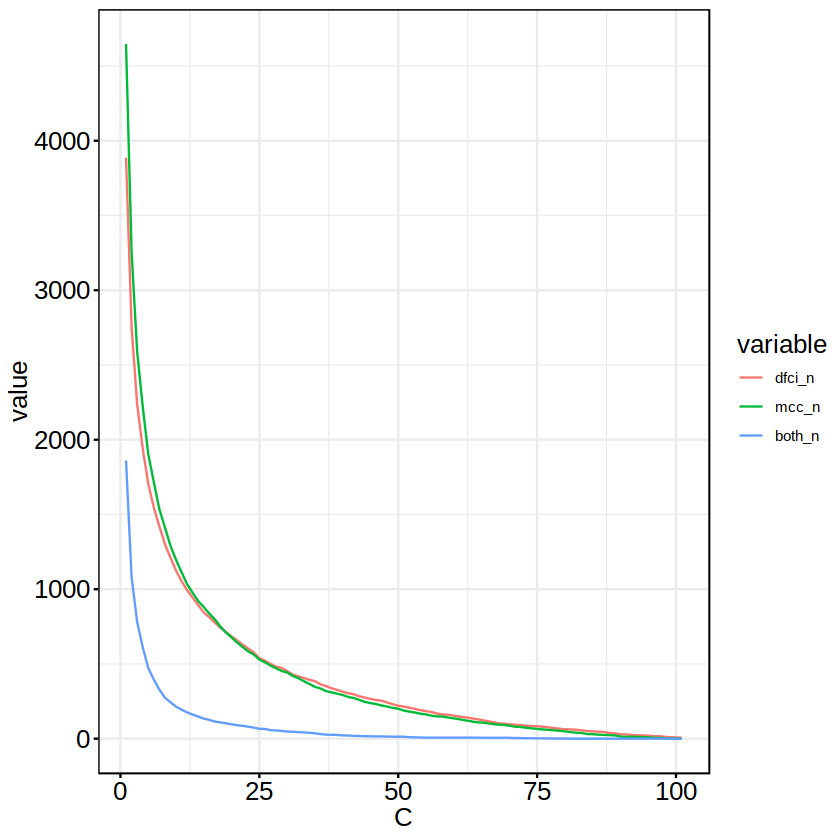

In [5]:
CUTOFF = 10

results = list()

for (C in c(0:100)){
    dfci_markers = sum_all %>% 
        filter(DFCI > C) %>%
        pull(gene_name)

    mcc_markers = sum_all %>% 
        filter(MCC > C) %>%
        pull(gene_name)

    dfci_n = dfci_markers %>% length
    mcc_n = mcc_markers %>% length

    both_n = intersect(dfci_markers, mcc_markers) %>% length

    results[[C+1]] = c("C" = C, "dfci_n" = dfci_n, "mcc_n" = mcc_n, "both_n" = both_n)
}

results = do.call(rbind, results) %>% data.frame() %>% mutate(C = C+1)
results %>% 
    reshape2::melt(id.vars="C") %>%
    ggplot(aes(x=C, y=value, color=variable)) +
    geom_line() +
    theme_cfrna_slides() +
    theme(legend.position = "right") 

In [6]:
C = 50
dfci_markers = sum_all %>% 
    filter(DFCI > C) %>%
    pull(gene_name)

mcc_markers = sum_all %>% 
    filter(MCC > C) %>%
    pull(gene_name)

dfci_markers %>% length
mcc_markers %>% length

intersect(dfci_markers, mcc_markers) %>% length


[1] 215

[1] 188

[1] 13

In [7]:
sum_all %>% select(!sum) %>% 

    filter(gene_name %in% c("RHD","CCL21")) %>% 
    mutate(gene_name = factor(gene_name, levels = c("RHD","CCL21"))) %>%
    # mutate(origin = factor(origin, levels = c("DFCI","MCC"))) %>%

    reshape2::melt(id.vars = c("gene_name","rank")) %>%
    rename(origin = variable, number_of_models = value) %>% head()

,gene_name,rank,origin,number_of_models
,<fct>,<int>,<fct>,<dbl>
1,RHD,1,DFCI,97
2,CCL21,2,DFCI,94
3,RHD,1,MCC,80
4,CCL21,2,MCC,74


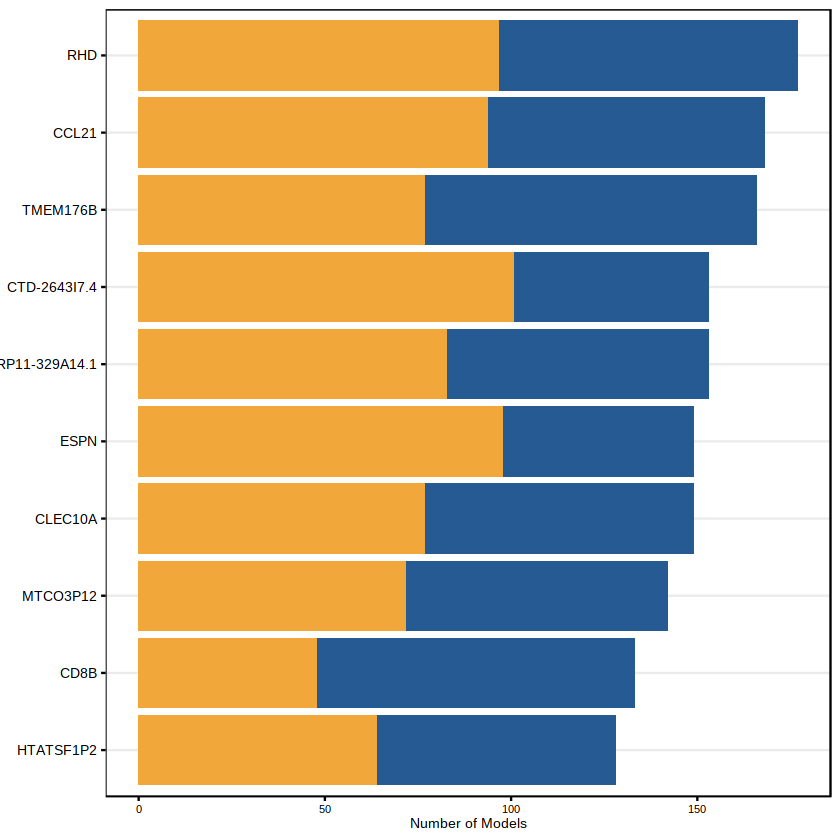

In [8]:
CUTOFF = 10

top_markers = sum_all %>% filter(rank <= CUTOFF) %>% pull(gene_name)


count_plt = sum_all %>% select(!sum) %>% 

    filter(gene_name %in% top_markers) %>% 
    mutate(gene_name = factor(gene_name, levels = top_markers)) %>%

    reshape2::melt(id.vars = c("gene_name","rank")) %>%
    rename(origin = variable, number_of_models = value) %>%

    mutate(origin = factor(origin, levels = c("MCC","DFCI"))) %>%
    mutate(gene_name = factor(gene_name, levels = rev(top_markers))) %>%
    
    ggplot(aes(x=number_of_models, y=gene_name, fill=origin)) +
    geom_bar(stat="identity", position="stack") +
    theme_cfrna_print()+
    labs(x="Number of Models")+
    theme(axis.title.y=element_blank(),
        axis.text.y = element_text(size = 8),
        panel.grid.major.x = element_blank()
        )+
    scale_fill_manual(values = COLORs)

count_plt

ggsave("./figures/Model_selections.pdf",width=2.75,height=4)

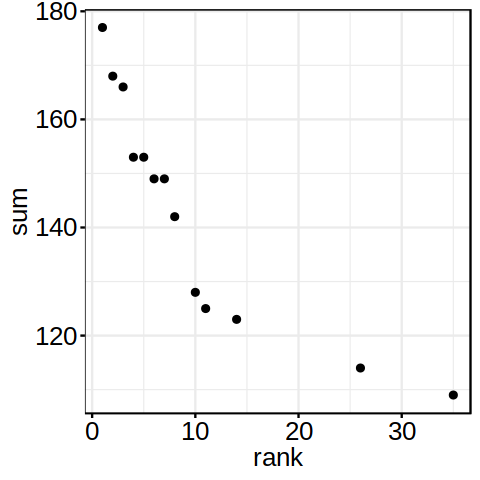

In [9]:
options(repr.plot.height = 4, repr.plot.width = 4)

sum_all %>% 
    filter(DFCI > 50 & MCC > 50) %>% 
    ggplot(aes(x=rank,y=sum))+
    geom_point() + 
    theme_cfrna_slides()

In [10]:
### lists

# top 2
l1 = sum_all %>% 
    head(2) %>% 
    pull(gene_name)

# DFCI > 50, MCC > 50 (n=13)
l2 = sum_all %>% 
    filter(DFCI > 50 & MCC > 50) %>% 
    pull(gene_name)

# top 50 by rank DFCI > 25 & MCC > 25
l3 = sum_all %>% 
    filter(DFCI > 25 & MCC > 25) %>% 
    head(50) %>%
    pull(gene_name)

l4 = sum_all %>% 
    head(100) %>% 
    pull(gene_name)

In [11]:
lapply(list(l1,l2,l3,l4),function(x) {
    cat(paste(x,collapse=", "))
    cat("\n")}
    
    )

RHD, CCL21
RHD, CCL21, TMEM176B, CTD-2643I7.4, RP11-329A14.1, ESPN, CLEC10A, MTCO3P12, HTATSF1P2, KCNQ1OT1, ANKRD36BP2, RNF182, RNA5SP149
RHD, CCL21, TMEM176B, CTD-2643I7.4, RP11-329A14.1, ESPN, CLEC10A, MTCO3P12, CD8B, HTATSF1P2, KCNQ1OT1, Y_RNA, MSC, ANKRD36BP2, EVPL, MYH11, ATOH8, TEAD4, Y_RNA, ZBED6, RNF182, MTRNR2L1, RNA5SP145, RPL9P9, MYCL, RNA5SP149, CDC42EP1, SPOCD1, GALNT3, DDX11L10, PCDH17, DNAJB5, MTND4P12, C19orf33, MT-RNR2, PDZK1IP1, KRT1, SLC15A2, DEPP1, BAHCC1, ERAP2, IGHD, MYO10, CFD, RP11-712B9.2, SRGAP1, RNF152, RN7SL736P, RN7SL665P, TRIP13
RHD, CCL21, TMEM176B, CTD-2643I7.4, RP11-329A14.1, ESPN, CLEC10A, MTCO3P12, CD8B, HTATSF1P2, KCNQ1OT1, Y_RNA, MSC, ANKRD36BP2, EVPL, TNNT1, TSPAN2, MYH11, ATOH8, TEAD4, LINS1, BRSK1, Y_RNA, ZBED6, TMEM205, RNF182, MTRNR2L1, PVALB, RP11-678G14.3, ALB, RNA5SP145, MYOM2, RPL9P9, MYCL, RNA5SP149, CDC42EP1, ABO, SPOCD1, GALNT3, DDX11L10, PCDH17, RP11-452G18.2, DNAJB5, SMIM24, MS4A1, IGHA1, MTND4P12, DDX11L2, HLA-J, Y_RNA, Y_RNA, C19orf3

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

---
# Custom Score

### make counts df

In [12]:
EVENTS = c("3M","6M","taper_start","taper_end","post_taper")

In [13]:
GENEs = c("RHD","CCL21")

GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = edgeR::cpm(counts)

### Combine counts with metadata
cnt_df = merge(mdf %>% select(sample_id, date_Lgvhd, expGroup, timepoint), data.frame(t(CNTS[GENEIDS,])), by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_Lgvhd", "expGroup","timepoint"), variable.name = "gene_id",value.name = "counts")

### Add gene names for plotting
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs))

## Plot Genes

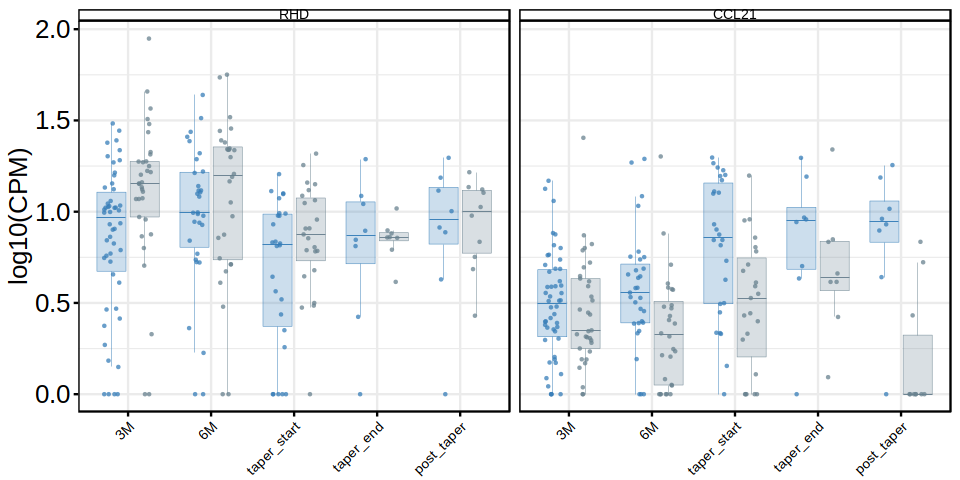

In [14]:

options(repr.plot.width=8, repr.plot.height=4)

### Make plot
cnt_df %>% 
    filter(timepoint %in% EVENTS) %>%
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>%
    ggplot(aes(x=timepoint, y=log10(counts+1), fill = expGroup, color=expGroup))+
    geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.25, size = 0.1) +

    geom_point(size = 1, alpha = 0.75, stroke=NA,
                position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.2, 
                                                seed=42)
                )+
    theme_cfrna_slides()+
    labs(y = "log10(CPM)")+
    theme(
        axis.text.x = element_text(size = 8, angle = 45, hjust = 1),
        axis.title.x = element_blank(),
        strip.text = element_text(size = 8, vjust = 1)
        )+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)+
    facet_wrap(~gene_name, ncol=2)

# ### Save
WIDTH = 4.5
HEIGHT= 2.3

ggsave("figures/OVERLAP_RHD_CCL21.pdf", width=WIDTH, height=HEIGHT, units="in")

## Plot Custom Score

In [15]:
ccl21 = cnt_df %>% filter(gene_name == "CCL21") %>% select(sample_id, counts) %>% rename(CCL21 = counts)
rhd = cnt_df %>% filter(gene_name == "RHD") %>% select(sample_id, counts) %>% rename(RHD = counts)

df = merge(ccl21, rhd, by="sample_id")

mdf_best = merge(mdf, df, by="sample_id") %>% 
    select(sample_id, ORIGIN, Record_ID, timepoint, date, date_Lgvhd,rel_Lgvhd, RHD, CCL21) %>% 
    mutate(rhd_ccl21_frac = (CCL21+1)/(RHD+1)) %>% 
    mutate(expGroup = ifelse(is.na(date_Lgvhd),"GVHD-","GVHD+")) %>% 
    filter(timepoint %in% EVENTS) %>%
    mutate(timepoint = factor(timepoint, levels = EVENTS))

mdf_best = mdf_best %>% 
    mutate(expGroup_sym = case_when(
        expGroup == "GVHD+" & ORIGIN == "DFCI" ~"GVHD+\nn=81",
        expGroup == "GVHD+" & ORIGIN == "MCC" ~"GVHD+\nn=42",
        expGroup == "GVHD-" & ORIGIN == "DFCI" ~"GVHD-\nn=61",
        expGroup == "GVHD-" & ORIGIN == "MCC" ~"GVHD-\nn=41")) %>% 
    mutate(expGroup_sym = factor(expGroup_sym, levels = c("GVHD-\nn=61","GVHD-\nn=41","GVHD+\nn=81","GVHD+\nn=42"))) 
    
mdf_best %>% head

,sample_id,ORIGIN,Record_ID,timepoint,date,date_Lgvhd,rel_Lgvhd,RHD,CCL21,rhd_ccl21_frac,expGroup,expGroup_sym
,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
1,gvhd_hct_cfrna_102_bp61x61,DFCI,19,3M,2018-12-14,NA,NA,35.757988,2.4242703,0.09315718,GVHD-,GVHD- n=61
2,gvhd_hct_cfrna_103_bp61x61,DFCI,29,3M,2018-12-19,2019-10-20,-305,18.145939,2.2682423,0.17070160,GVHD+,GVHD+ n=81
3,gvhd_hct_cfrna_111_bp61x61,DFCI,14,6M,2019-02-07,NA,NA,2.015897,2.0158974,1.00000000,GVHD-,GVHD- n=61
4,gvhd_hct_cfrna_133_bp61x61,DFCI,72,3M,2019-05-21,NA,NA,0.000000,4.2626109,5.26261093,GVHD-,GVHD- n=61
5,gvhd_hct_cfrna_143_bp61x61,DFCI,50,3M,2019-03-06,2019-06-05,-91,15.371561,0.4854177,0.09073159,GVHD+,GVHD+ n=81
6,gvhd_hct_cfrna_144_bp61x61,DFCI,21,6M,2019-03-01,NA,NA,55.342800,3.0408132,0.07171836,GVHD-,GVHD- n=61


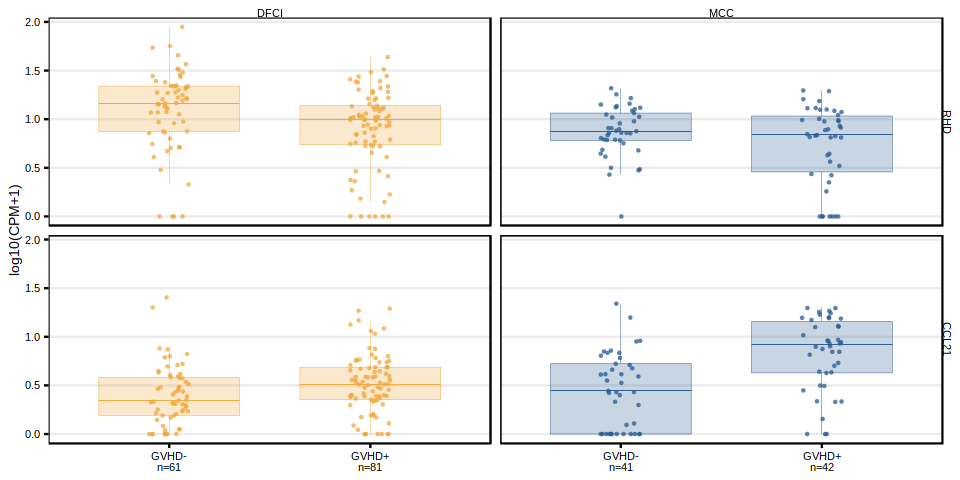

In [16]:
mdf_best %>% 
    select(sample_id, ORIGIN, expGroup, expGroup_sym, RHD, CCL21) %>% 
    reshape2::melt(.,id.vars = c("sample_id","ORIGIN","expGroup","expGroup_sym"), variable.name = "gene", value.name = "counts") %>%
        ggplot(aes(x=expGroup_sym, y=log10(counts+1)))+
        geom_boxplot(aes(fill = ORIGIN, color=ORIGIN),
                    outlier.shape = NA, 
                    position = position_dodge(width = 0.8), 
                    width = 0.7, alpha = 0.25, size = 0.1) +
        geom_point(aes(fill = ORIGIN, color=ORIGIN),
                    size = 1, alpha = 0.75, stroke=NA,
                    position =  position_jitterdodge(jitter.height=0, 
                                                    jitter.width=.2, 
                                                    seed=42)
                    )+
        theme_cfrna_print()+
        labs(y = "log10(CPM+1)")+
        theme(
            # axis.text.x = element_text(size = 6, angle = 45, hjust = 1), 
            axis.title.x = element_blank(),
            panel.grid.major.x = element_blank(),             # Remove minor gridlines
            strip.text = element_text(size = 6, vjust = 1)
            )+
        scale_fill_manual(values = COLORs) +
        scale_color_manual(values = COLORs) +
        facet_grid(gene~ORIGIN, scales = "free_x", space = "free_x")

ggsave("./figures/RHD_CCL21_counts.pdf", width = 4.5, height = 4.5, units = "in")

Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”
Warning message in wilcox.test.default(c(0.125674516391344, 0.154951355181051, 0.210349571594379, :
“cannot compute exact p-value with ties”


Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”
Warning message in wilcox.test.default(c(0.125674516391344, 0.154951355181051, 0.210349571594379, :
“cannot compute exact p-value with ties”


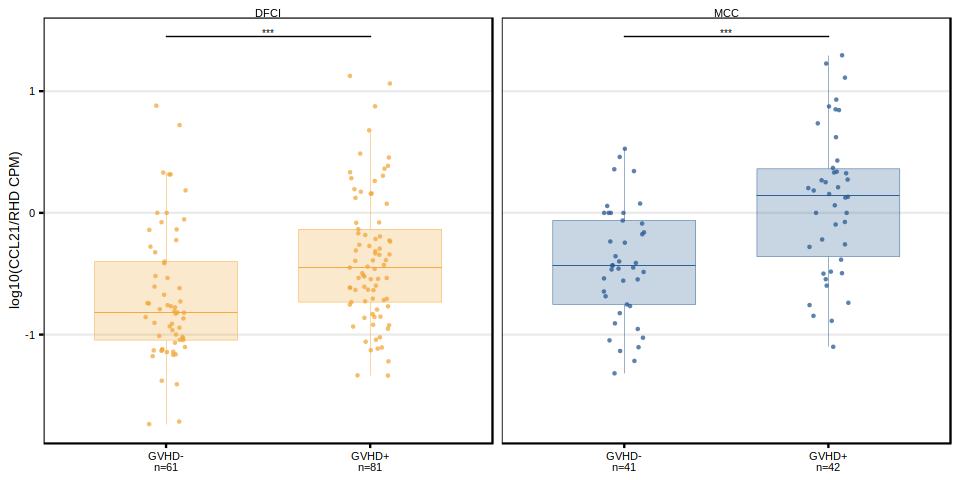

In [17]:
score_plt = mdf_best %>% 
    # filter(timepoint %in% EVENTS) %>%
    # mutate(timepoint = gsub("_","\n",timepoint)) %>% 
    # mutate(timepoint = factor(timepoint, levels = gsub("_","\n",EVENTS))) %>%

    ggplot(aes(x=expGroup_sym, y=log10(rhd_ccl21_frac)))+
    geom_boxplot(aes(fill = ORIGIN, color=ORIGIN),
                outlier.shape = NA, 
                position = position_dodge(width = 0.8), 
                width = 0.7, alpha = 0.25, size = 0.1) +
    geom_point(aes(fill = ORIGIN, color=ORIGIN),
                size = 1, alpha = 0.75, stroke=NA,
                position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.2, 
                                                seed=42)
                )+
    theme_cfrna_print()+
    labs(y = "log10(CCL21/RHD CPM)")+
    theme(
        # axis.text.x = element_text(size = 6, angle = 45, hjust = 1), 
        axis.title.x = element_blank(),
        panel.grid.major.x = element_blank(),             # Remove minor gridlines
        strip.text = element_text(size = 6, vjust = 1)
        )+
    scale_fill_manual(values = COLORs) +
    scale_color_manual(values = COLORs) +
    facet_grid(~ORIGIN, scales = "free_x", space = "free_x")


my_comparisons <- list(  c("GVHD-\nn=61", "GVHD+\nn=81")  )
score_plt = score_plt + stat_compare_means(
        comparisons = my_comparisons,
        label = "p.format",
        method = "wilcox.test",
        symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
        size = 2,
        tip.length = 0,
        rm.na= TRUE,
        vjust = 0.5,
)

my_comparisons <- list( c("GVHD+\nn=42", "GVHD-\nn=41")  )
score_plt = score_plt + stat_compare_means(
        comparisons = my_comparisons,
        label = "p.format",
        method = "wilcox.test",
        symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
        size = 2,
        tip.length = 0,
        rm.na= TRUE,
        vjust = 0.5,
)


# ### Save
WIDTH = 2.38
HEIGHT= 2 

score_plt

ggsave("figures/OVERLAP_score.pdf", width=WIDTH, height=HEIGHT, units="in")

Warning message in wilcox.test.default(c(-0.0874873043401737, -0.356163645697686, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(-0.0874873043401737, -0.356163645697686, :
“cannot compute exact p-value with ties”


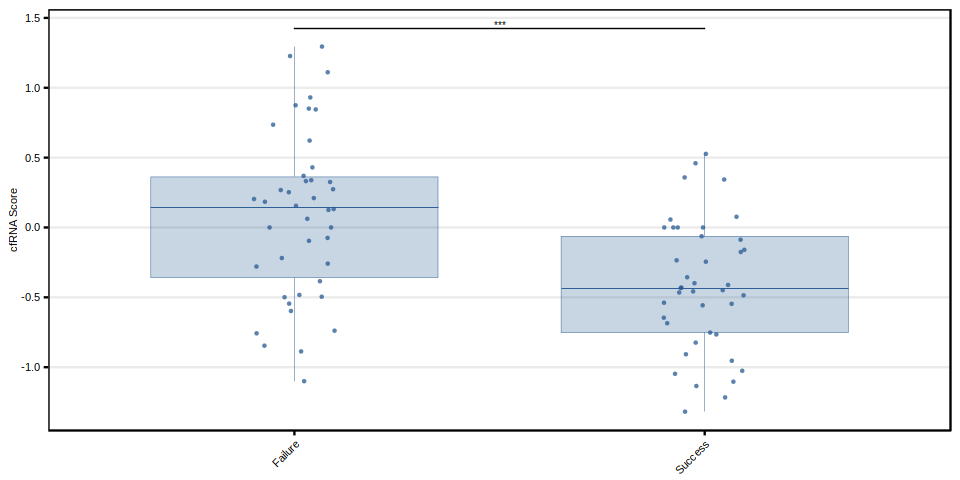

In [18]:
score_plt = mdf_best %>% 
    filter(timepoint %in% EVENTS) %>%
    filter(ORIGIN == "MCC") %>%
    mutate(expGroup_sym = ifelse(grepl("-",expGroup_sym),"Success","Failure")) %>%
    # mutate(timepoint = gsub("_","\n",timepoint)) %>% 
    # mutate(timepoint = factor(timepoint, levels = gsub("_","\n",EVENTS))) %>%

    ggplot(aes(x=expGroup_sym, y=log10(rhd_ccl21_frac)))+
    geom_boxplot(aes(fill = ORIGIN, color=ORIGIN),
                outlier.shape = NA, 
                position = position_dodge(width = 0.8), 
                width = 0.7, alpha = 0.25, size = 0.1) +
    geom_point(aes(fill = ORIGIN, color=ORIGIN),
                size = 1, alpha = 0.75, stroke=NA,
                position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.2, 
                                                seed=42)
                )+
    theme_cfrna_print()+
    labs(y = "cfRNA Score")+
    theme(
        axis.text.x = element_text(size = 6, angle = 45, hjust = 1), 
        axis.title.x = element_blank(),
        panel.grid.major.x = element_blank(),             # Remove minor gridlines
        axis.title.y = element_text(size = 6)
        )+
    scale_fill_manual(values = COLORs) +
    scale_color_manual(values = COLORs) 

my_comparisons <- list( c("Success", "Failure")  )
score_plt = score_plt + stat_compare_means(
        comparisons = my_comparisons,
        label = "p.format",
        method = "wilcox.test",
        symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
        size = 2,
        tip.length = 0,
        rm.na= TRUE,
        vjust = 0.5,
)


# ### Save
WIDTH = 1
HEIGHT= 1.75

score_plt

ggsave("figures/OVERLAP_score.RMX.png", width=WIDTH, height=HEIGHT, units="in")

## KM plots

In [19]:
library(survminer)
library(lubridate)

In [20]:
GRP = "DFCI"
GRP = "MCC"



km_df = mdf_best %>% 
    filter(ORIGIN == GRP) %>%
    select(sample_id, Record_ID, rel_Lgvhd, expGroup, rhd_ccl21_frac) %>% 
    mutate(rhd_ccl21_frac = log10(rhd_ccl21_frac)) %>% 
    mutate(rel_Lgvhd = -rel_Lgvhd) 
    
median = median(km_df$rhd_ccl21_frac, na.rm = TRUE)
    
km_df = km_df %>% mutate(quant = ifelse(rhd_ccl21_frac < median, "Low","High"))

# Replace NA in failure_days with an appropriate censoring indicator
km_df$censor = ifelse(is.na(km_df$rel_Lgvhd),0,1)

# Replace NA in failure_days with some large value (to ensure censored individuals are included in the survival calculation):
MAX_DAYS <- max(km_df$rel_Lgvhd, na.rm = TRUE)
km_df$rel_Lgvhd[is.na(km_df$rel_Lgvhd)] <- MAX_DAYS + 100

# Create the survival object
surv_obj <- survival::Surv(time = km_df$rel_Lgvhd, event = km_df$censor)

# Fit the survival curve, split by the 'quant' group
fit <- survival::survfit(surv_obj ~ quant, data = km_df)

## create new theme based on theme_cfrna_print() that removed minor gridlines
theme_cfrna_print_no_minor <- theme_cfrna_print() + theme(panel.grid.minor = element_blank(), axis.title.x= element_blank())

# Plot the KM curve with censoring information
km_plt_mcc <- ggsurvplot(fit, data = km_df, 
        #    legend.title = "Classifier Score:", 
        #    legend.labs = c("Low",  "High"),
        palette = c("#E97451","#69818F"),
            legend = "none",
           xlab = "Days", 
           ylab = "Survival Probability",
           conf.int = TRUE,
           censor = TRUE,          # Show censoring marks
           pval = FALSE, 
           risk.table = FALSE,      # Add risk table below the plot
           xlim = c(0,MAX_DAYS+100),
           ggtheme = theme_cfrna_print_no_minor)

ggsave(paste0("./figures/KM_curve_",GRP,".pdf"), km_plt_mcc$plot, width = 2.15, height = 1.5, units = "in")

Area under the curve: 67.86%
Area under the curve: 73.81%


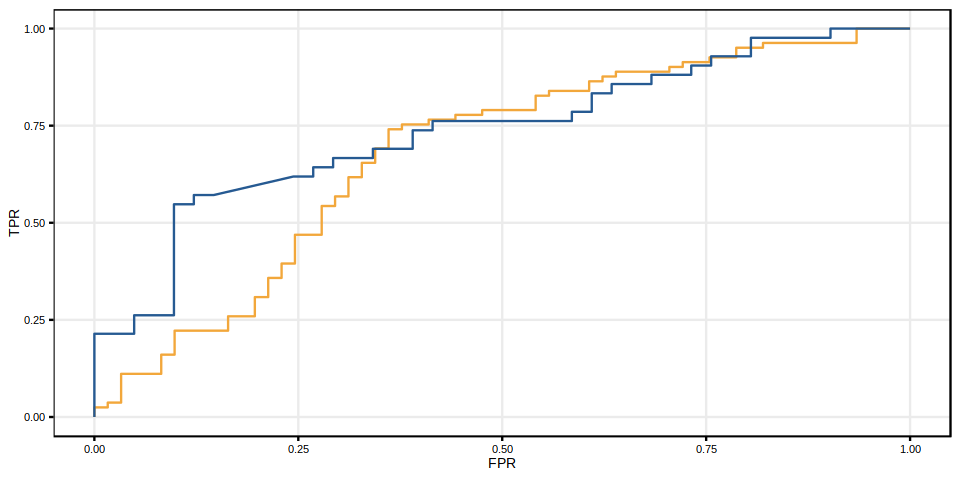

In [21]:
suppressMessages(library(pROC))
##------------------------------------
## ROC plot
##------------------------------------

dfci_mdf = mdf_best %>% filter(ORIGIN == "DFCI")
roc_dfci <- suppressMessages(roc(response = dfci_mdf$expGroup, predictor = dfci_mdf$rhd_ccl21_frac,
                percent=TRUE,
                ci=TRUE, 
                boot.n=10000, boot.stratified=TRUE,
                print.auc=TRUE,
                print.thres="best",
                print.thres.best.method="youden"))

mcc_mdf = mdf_best %>% filter(ORIGIN == "MCC")
roc_mcc <- suppressMessages(roc(response = mcc_mdf$expGroup, predictor = mcc_mdf$rhd_ccl21_frac,
                percent=TRUE,
                ci=TRUE, 
                boot.n=10000, boot.stratified=TRUE,
                print.auc=TRUE,
                print.thres="best",
                print.thres.best.method="youden"))

##------------------------------------
## get roc values
##------------------------------------

dfci_roc <- data.frame("sensitivity" = roc_dfci$sensitivities,
                        "specificity" = roc_dfci$specificities,
                       "set" = "DFCI")

mcc_roc <- data.frame("sensitivity" = roc_mcc$sensitivities,
                        "specificity" = roc_mcc$specificities,
                       "set" = "MCC")


all_roc <- do.call("rbind",list(dfci_roc, mcc_roc)) %>%
    mutate(FPR = 1-(as.numeric(specificity)/100),
          TPR = as.numeric(sensitivity)/100)

## for sbir
all_roc %>% write.csv("/workdir/cjl332/SBIR/PAPER-Click_202504/GVHD_AUC.csv",row.names=FALSE)

## malke plot

auc_plt = all_roc %>% 
    mutate(set = factor(set,levels = c("DFCI","MCC"))) %>% 
    ggplot(aes(x= FPR, y= TPR, group = set, linetype = set, color = set))+
    geom_path()+
    theme_cfrna_print()+
    theme(
                strip.text = element_text(size = 8),
        )+
    scale_linetype_manual(values = c("MCC"="solid","DFCI"="solid"))+
    scale_color_manual(values = c("DFCI"="#f2a73b","MCC"="#265a92"))+
    theme(panel.grid.minor  = element_blank()) 
  
WIDTH = 2.1
HEIGHT = 2
auc_plt
ggsave("./figures/SCORE_ROC.pdf", width = WIDTH, height = HEIGHT)

print(roc_dfci$auc)
print(roc_mcc$auc)

In [22]:
youden_threshold <- coords(roc_dfci, x="best", input="threshold", best.method="youden")$threshold
youden_threshold

[1] 0.1874905

In [27]:
X = roc_dfci
X = roc_mcc

youden_threshold <- coords(X, x="best", input="threshold", best.method="youden")$threshold

tmp = data.frame(sensitivity = X$sensitivities,
                 specificity = X$specificities,
                 threshold = X$thresholds) 
tmp %>% head

,sensitivity,specificity,threshold
,<dbl>,<dbl>,<dbl>
1,100.00000,0.000000,-Inf
2,100.00000,2.439024,0.05441340
3,100.00000,4.878049,0.06705473
4,100.00000,7.317073,0.07604744
5,100.00000,9.756098,0.07906735
6,97.61905,9.756098,0.08452689


In [15]:
library(patchwork)

Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”


Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”
Warning message in wilcox.test.default(c(0.125674516391344, 0.154951355181051, 0.210349571594379, :
“cannot compute exact p-value with ties”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”
Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”
Warning message in wilcox.test.default(c(0.125674516391344, 0.154951355181051, 0.210349571594379, :
“cannot compute exact p-value with ties”


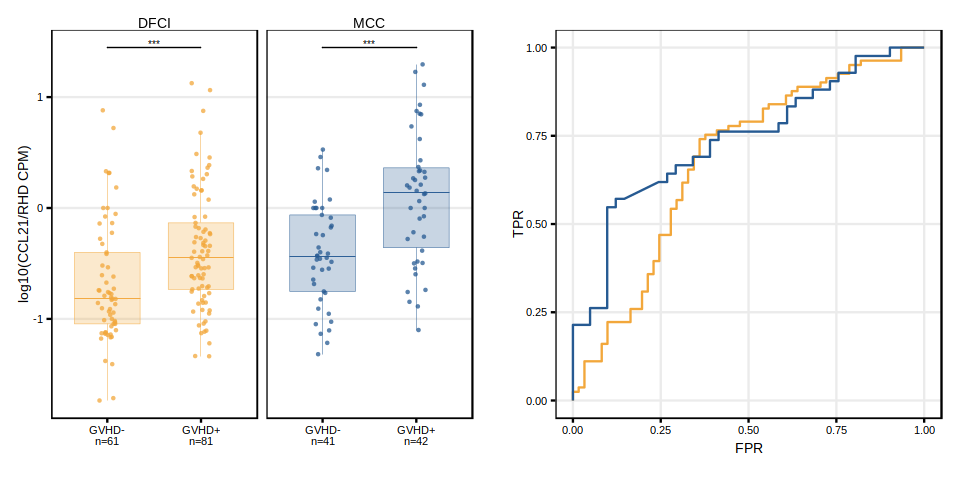

In [47]:
auc_plt = auc_plt + theme(axis.title.x = element_text(size = 8, vjust = 5))
score_plt = score_plt + theme(strip.text = element_text(size = 8))

plt_all = score_plt+ plot_spacer() + auc_plt
plt_all + plot_layout(widths = c(6, 0.05, 5.5), nrow = 1)


ggsave("./figures/OVERLAP_toprow.pdf", width = 4.15, height = 2.2)

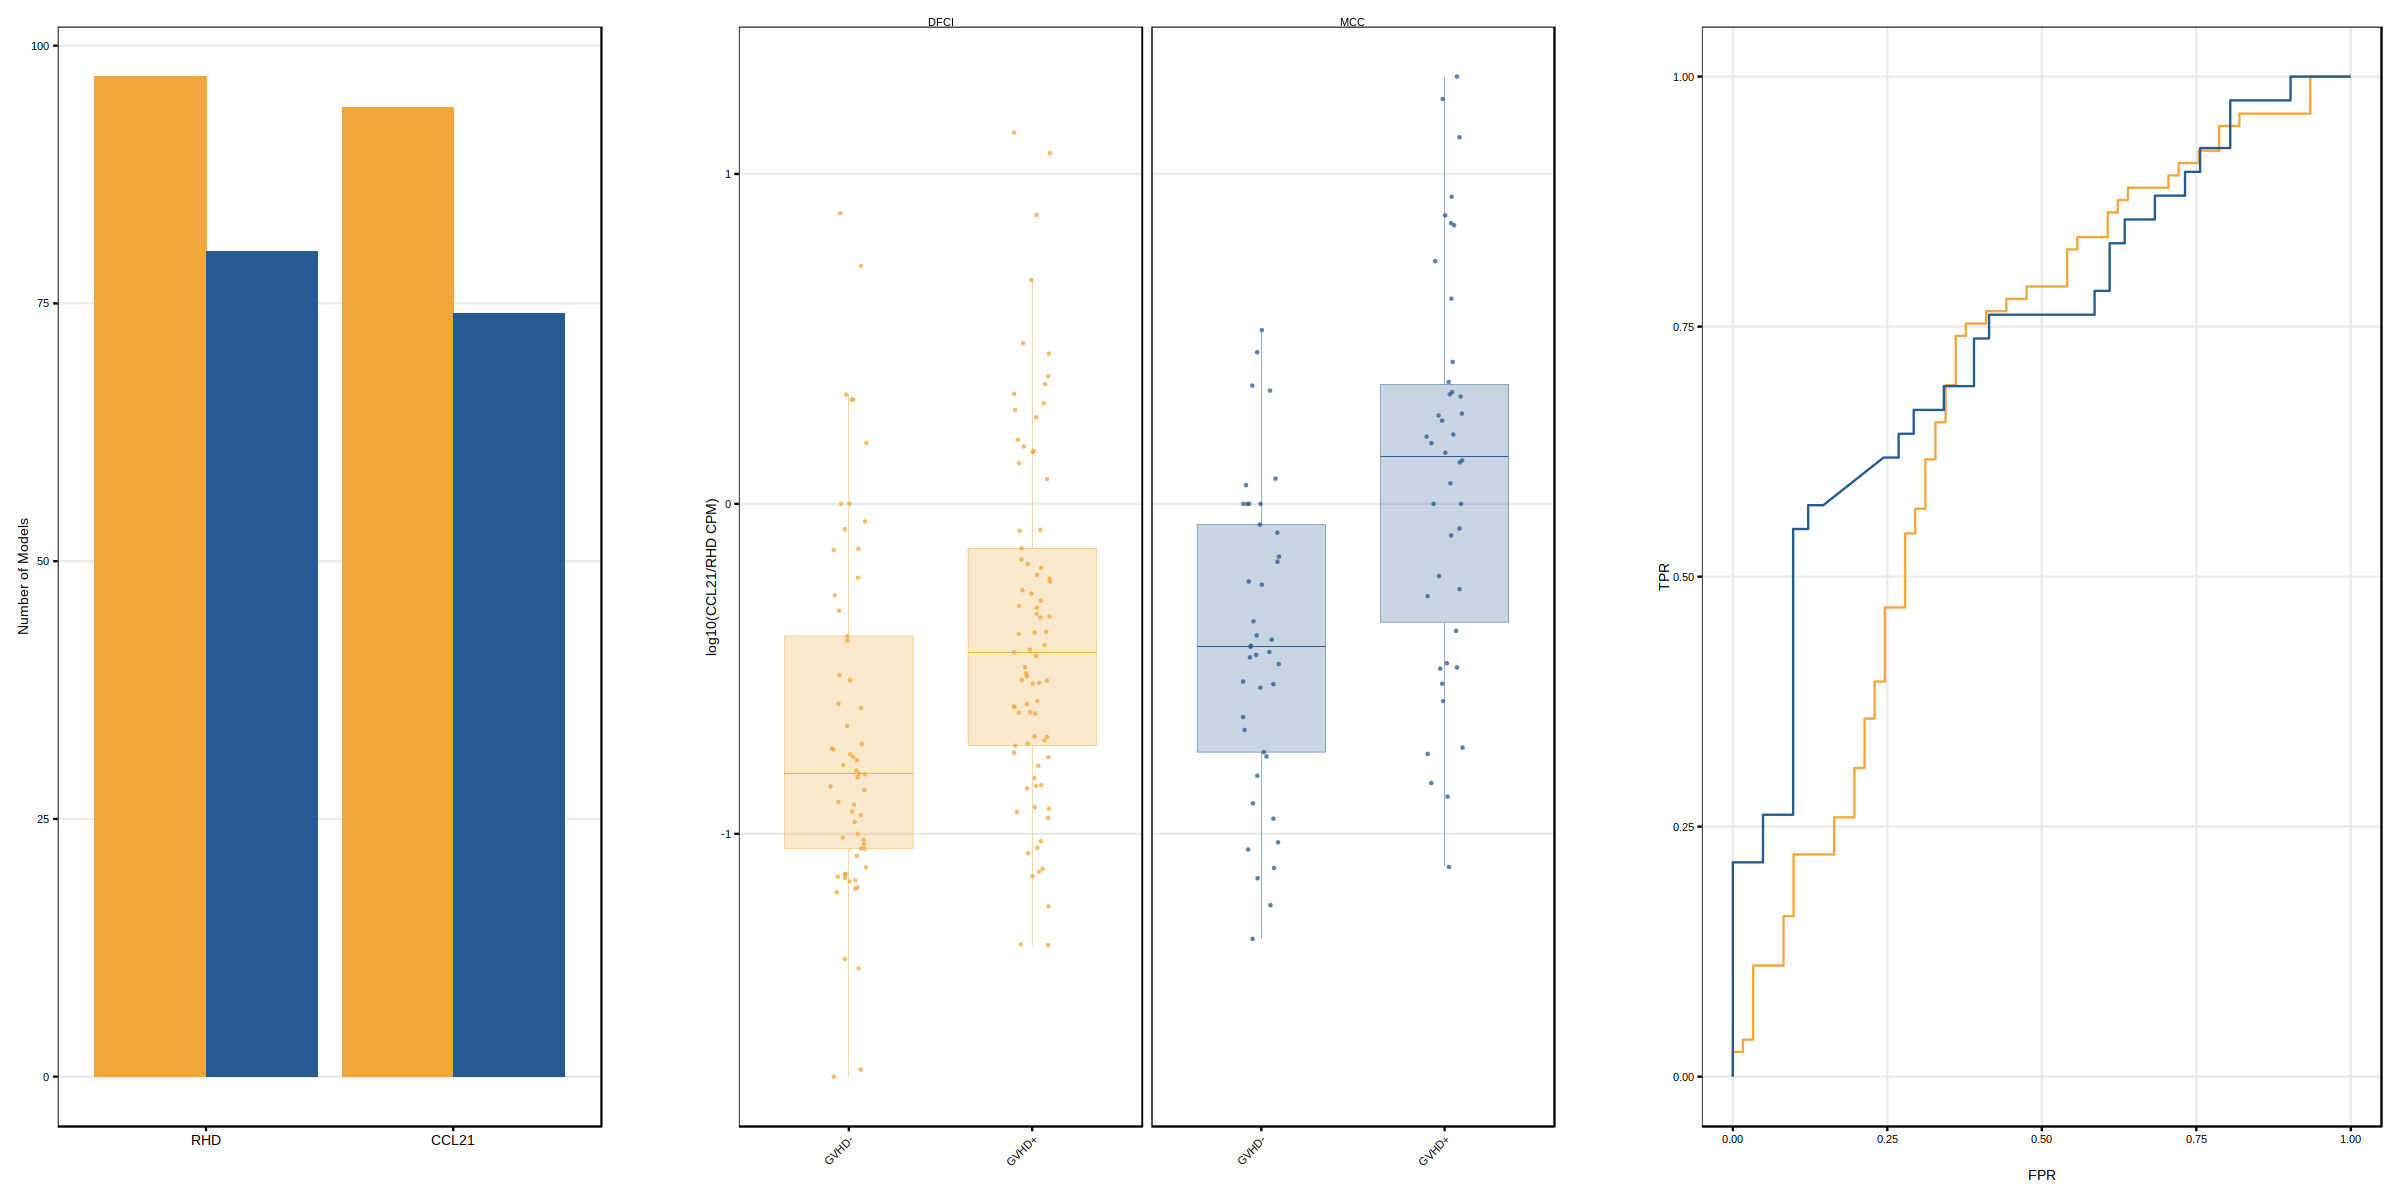

In [ ]:

plt_all = count_plt + plot_spacer() + score_plt+ plot_spacer() + auc_plt
plt_all + plot_layout(widths = c(4, 0.5 ,6, 0.5, 5), nrow = 1)
b

ggsave("./figures/OVERLAP_toprow.pdf", width = 7, height = 2.75)

---
# RBC 

In [59]:
GENEs = c("RHD","HBB","CCL21")

GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = edgeR::cpm(counts)

### Combine counts with metadata
cnt_df = merge(mdf %>% select(sample_id, date_Lgvhd, expGroup, timepoint,ORIGIN), data.frame(t(CNTS[GENEIDS,])), by.x="sample_id",by.y=0) %>% 
    filter(timepoint == "taper_start" | ORIGIN == "DFCI") %>% select(!ORIGIN) %>% 
    reshape2::melt(id.vars = c("sample_id","date_Lgvhd", "expGroup","timepoint"), variable.name = "gene_id",value.name = "counts")

### Add gene names for plotting
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs))

In [60]:
hbb = cnt_df %>% filter(gene_name == "HBB") %>% select(sample_id, counts) %>% rename(HBB = counts)
rhd = cnt_df %>% filter(gene_name == "RHD") %>% select(sample_id, counts) %>% rename(RHD = counts)
ccl21 = cnt_df %>% filter(gene_name == "CCL21") %>% select(sample_id, counts) %>% rename(CCL21 = counts)


df = merge(hbb, rhd, by="sample_id")
df = merge(df, ccl21, by="sample_id")

mdf_best = merge(mdf, df, by="sample_id") %>% 
    select(sample_id, ORIGIN, Record_ID, timepoint, date, date_Lgvhd, rel_Lgvhd, RHD, HBB,CCL21) %>% 
    mutate(expGroup = ifelse(is.na(date_Lgvhd),"GVHD-","GVHD+")) %>% 
    filter(timepoint %in% EVENTS) %>%
    mutate(timepoint = factor(timepoint, levels = EVENTS))

mdf_best = mdf_best %>% 
    mutate(expGroup_sym = case_when(
        expGroup == "GVHD+" & ORIGIN == "DFCI" ~"GVHD+\nn=81",
        expGroup == "GVHD+" & ORIGIN == "MCC" ~"GVHD+\nn=42",
        expGroup == "GVHD-" & ORIGIN == "DFCI" ~"GVHD-\nn=61",
        expGroup == "GVHD-" & ORIGIN == "MCC" ~"GVHD-\nn=41")) %>% 
    mutate(expGroup_sym = factor(expGroup_sym, levels = c("GVHD-\nn=61","GVHD-\nn=41","GVHD+\nn=81","GVHD+\nn=42"))) 
    
mdf_best %>% head

,sample_id,ORIGIN,Record_ID,timepoint,date,date_Lgvhd,rel_Lgvhd,RHD,HBB,CCL21,expGroup,expGroup_sym
,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<fct>
1,gvhd_hct_cfrna_1_bp51x51,DFCI,26,2M,2018-11-12,2019-10-07,-329,0.000000,9.669392,2.275151,GVHD+,GVHD+ n=81
2,gvhd_hct_cfrna_100_bp61x61,DFCI,72,2M,2019-04-24,NA,NA,1.169256,48466.813603,0.000000,GVHD-,GVHD- n=61
3,gvhd_hct_cfrna_101_bp61x61,DFCI,20,2M,2018-10-24,2019-04-10,-168,16.793075,22998.387323,3.250273,GVHD+,GVHD+ n=81
4,gvhd_hct_cfrna_102_bp61x61,DFCI,19,3M,2018-12-14,NA,NA,35.757988,10022.539653,2.424270,GVHD-,GVHD- n=61
5,gvhd_hct_cfrna_103_bp61x61,DFCI,29,3M,2018-12-19,2019-10-20,-305,18.145939,14752.648173,2.268242,GVHD+,GVHD+ n=81
6,gvhd_hct_cfrna_104_bp61x61,DFCI,30,PR,2018-09-14,2018-09-30,-16,30.873284,22022.574986,0.000000,GVHD+,GVHD+ n=81


In [61]:
rbc_metrics = metrics %>% select(sample_id,rbc_CBC)
rbc_decon = decon %>% select(sample_id,erythrocyte_erythroid_progenitor)

mdf_rbc = merge(mdf_best, rbc_metrics, by="sample_id")
mdf_rbc = merge(mdf_rbc, rbc_decon, by="sample_id")


In [62]:
VARs = c("RHD","HBB","CCL21","rbc_CBC","erythrocyte_erythroid_progenitor")
all_other = colnames(mdf_rbc)
all_other = all_other[!all_other %in% VARs]

mdf_rbc = mdf_rbc %>% 
    reshape2::melt(id.vars = all_other)

mdf_rbc %>% head

,sample_id,ORIGIN,Record_ID,timepoint,date,date_Lgvhd,rel_Lgvhd,expGroup,expGroup_sym,variable,value
,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<int>,<chr>,<fct>,<fct>,<dbl>
1,gvhd_hct_cfrna_1_bp51x51,DFCI,26,2M,2018-11-12,2019-10-07,-329,GVHD+,GVHD+ n=81,RHD,0.000000
2,gvhd_hct_cfrna_100_bp61x61,DFCI,72,2M,2019-04-24,NA,NA,GVHD-,GVHD- n=61,RHD,1.169256
3,gvhd_hct_cfrna_101_bp61x61,DFCI,20,2M,2018-10-24,2019-04-10,-168,GVHD+,GVHD+ n=81,RHD,16.793075
4,gvhd_hct_cfrna_102_bp61x61,DFCI,19,3M,2018-12-14,NA,NA,GVHD-,GVHD- n=61,RHD,35.757988
5,gvhd_hct_cfrna_103_bp61x61,DFCI,29,3M,2018-12-19,2019-10-20,-305,GVHD+,GVHD+ n=81,RHD,18.145939
6,gvhd_hct_cfrna_104_bp61x61,DFCI,30,PR,2018-09-14,2018-09-30,-16,GVHD+,GVHD+ n=81,RHD,30.873284


Warning message:
“Removed 33 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“Removed 33 rows containing missing values or values outside the scale range
(`geom_point()`).”


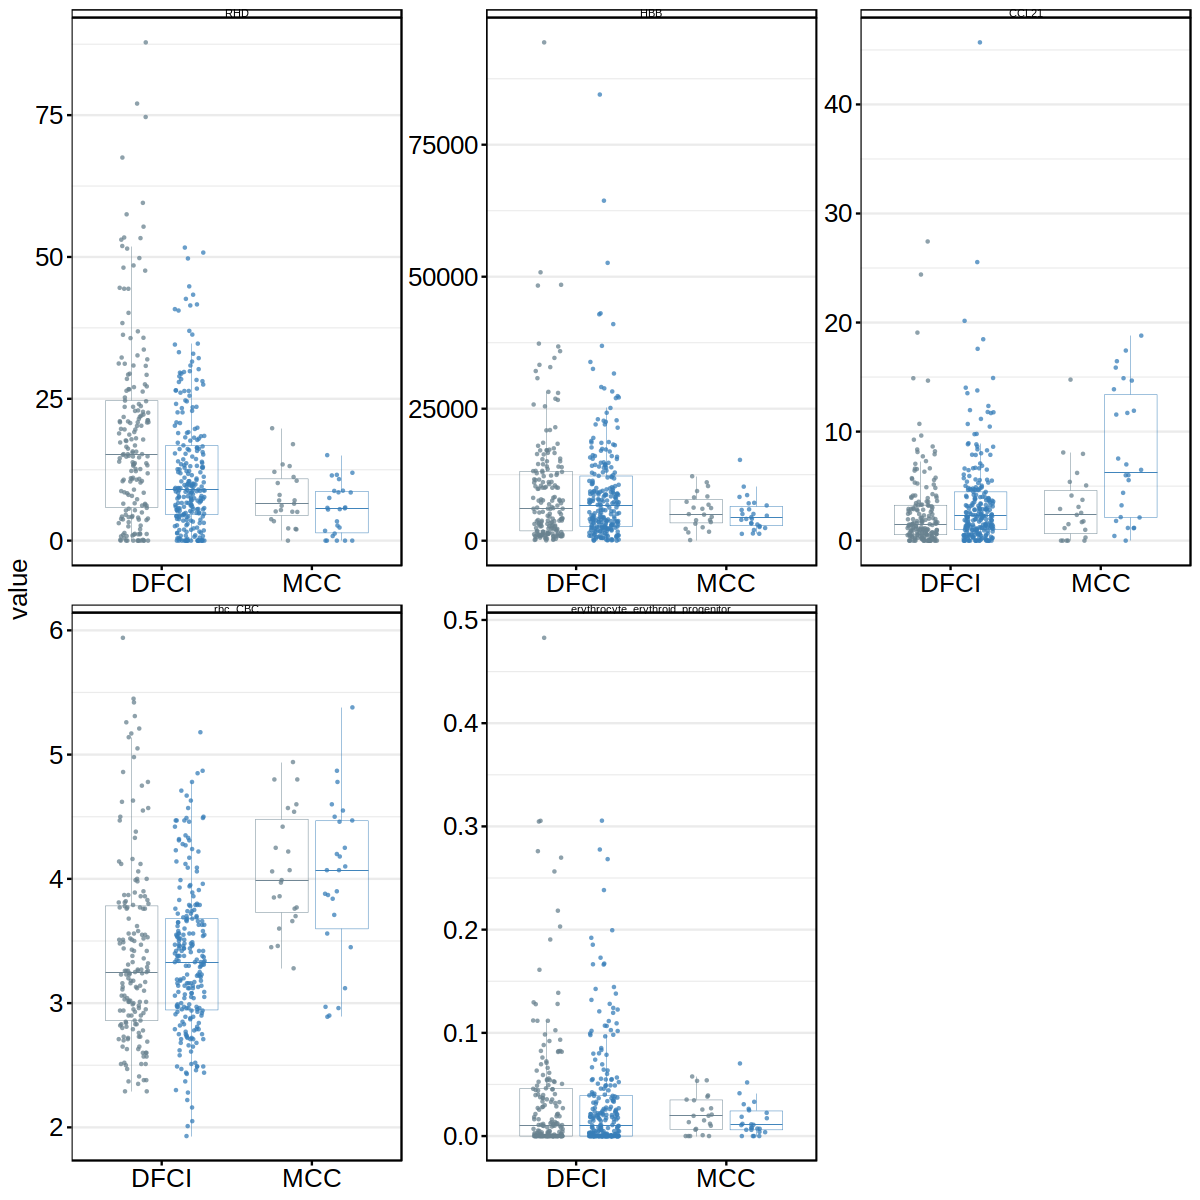

In [63]:
options(repr.plot.width = 10, repr.plot.height = 10)
mdf_rbc %>% 
    ggplot(aes(x=ORIGIN, y=value, color = expGroup))+
    geom_boxplot(,
                outlier.shape = NA, 
                position = position_dodge(width = 0.8), 
                width = 0.7, alpha = 0.25, size = 0.1) +
    geom_point(,
                size = 1, alpha = 0.75, stroke=NA,
                position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.2, 
                                                seed=42)
                )+
    theme_cfrna_slides()+
    theme(
        # axis.text.x = element_text(size = 6, angle = 45, hjust = 1), 
        axis.title.x = element_blank(),
        panel.grid.major.x = element_blank(),             # Remove minor gridlines
        strip.text = element_text(size = 6, vjust = 1)
        )+
    scale_fill_manual(values = COLORs) +
    scale_color_manual(values = COLORs) +
    facet_wrap(~variable, scales = "free")